## Segmentacja naczyń - architektura U-Net

In [36]:

import torch
print(torch.__version__)        # powinno być np. 2.x.x+cu124
print(torch.cuda.is_available()) # True

2.6.0+cu124
True


In [37]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 1024  # obrazy będą resize'owane do IMG_SIZE x IMG_SIZE
print(f"Device: {DEVICE}")

Device: cuda


## Wczytanie danych

In [38]:
images, masks = [], []
for i in range(1, 16):
    fname = f"0{i}_h" if i < 10 else f"{i}_h"
    img = cv.imread(f"dataset/healthy/{fname}.jpg")
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    mask = cv.imread(f"dataset/healthy_manualsegm/{fname}.tif", cv.IMREAD_GRAYSCALE)
    images.append(img)
    masks.append(mask)

print(f"Załadowano {len(images)} obrazów, rozmiar: {images[0].shape}")

Załadowano 15 obrazów, rozmiar: (2336, 3504, 3)


## Dataset

In [39]:
#preproces taki sam jak wczesniej 

In [ ]:
def preprocess_image(img_rgb):
    print("rozpoczynam preprocessing...")
    """Pełny preprocessing: kanał G → Laplacian → CLAHE → medianBlur"""
    img = cv.split(img_rgb)[1]  # kanał zielony

    # ROI mask (tło = ciemne piksele)
    roi_mask = np.zeros_like(img)
    roi_mask[img < 4] = 255
    roi_mask = ~roi_mask

    # Laplacian sharpening
    img = img - cv.Laplacian(img, cv.CV_64F) * 0.5
    img = cv.normalize(img, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

    # Normalizacja w ROI
    img_norm = normalize_masked(img, roi_mask)
    img_uint8 = (img_norm * 255).astype(np.uint8)

    # CLAHE + median blur
    clahe = cv.createCLAHE(clipLimit=3.5, tileGridSize=(10, 10))
    img_clahe = clahe.apply(img_uint8)
    img_clahe = cv.medianBlur(img_clahe, 3)
    print("preprocessing zakończony.")

    return img_clahe

def normalize_masked(img, mask):
    result = np.zeros_like(img, dtype=np.float32)
    
    pixels = img[mask > 0].astype(np.float32)
    
    min_val = pixels.min()
    max_val = pixels.max()
    
    result[mask > 0] = (pixels - min_val) / (max_val - min_val + 1e-8)
    
    return result  # wartości 0.0–1.0, poza maską = 0.0

class RetinaDataset(Dataset):
    def __init__(self, images, masks, img_size=512):
        self.img_size = img_size
        self.images = []
        self.masks = []
        for img, mask in zip(images, masks):
            # start preprocessing 
            img_clpied = img[:,128:-128]  # przycinamy czarne paski po bokach
            mask_clpied = mask[:,128:-128]
            img_clahe = preprocess_image(img_clpied)
            # koniec preprocessing 

            img_r = cv.resize(img_clahe, (img_size, img_size))
            mask_r = cv.resize(mask_clpied, (img_size, img_size), interpolation=cv.INTER_NEAREST)    

            img_t = torch.from_numpy(img_r).float().unsqueeze(0) / 255.0 
            mask_t = torch.from_numpy((mask_r > 0).astype(np.float32)).unsqueeze(0)
            self.images.append(img_t)
            self.masks.append(mask_t)


    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

aug_images = images[:12] + [cv.flip(img, 1) for img in images[:12]]
aug_masks  = masks[:12]  + [cv.flip(mask, 1) for mask in masks[:12]]


# podział train/test: 12 treningowe, 3 testowe
train_ds = RetinaDataset(aug_images, aug_masks, IMG_SIZE)  
test_ds  = RetinaDataset(images[12:], masks[12:], IMG_SIZE) 

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

print(f"Treningowych: {len(train_ds)}, testowych: {len(test_ds)}")

rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
rozpoczynam preprocessing...
preprocessing zakończony.
Treningowych: 24, testowych: 6


## Architektura U-Net

In [41]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.05),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        # encoder
        self.enc = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        ch = in_channels
        for f in features:
            self.enc.append(DoubleConv(ch, f))
            ch = f

        # bottleneck
        self.bottleneck =nn.Sequential(
            DoubleConv(features[-1], features[-1] * 2),
            nn.Dropout2d(p=0.25))

        # decoder
        self.dec_up   = nn.ModuleList()
        self.dec_conv = nn.ModuleList()
        rev = list(reversed(features))
        ch = features[-1] * 2
        for f in rev:
            self.dec_up.append(nn.ConvTranspose2d(ch, f, 2, stride=2))
            self.dec_conv.append(DoubleConv(f * 2, f))
            ch = f

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for layer in self.enc:
            x = layer(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skips = skips[::-1]
        for i, (up, conv) in enumerate(zip(self.dec_up, self.dec_conv)):
            x = up(x)
            x = torch.cat([skips[i], x], dim=1)
            x = conv(x)

        return self.final(x)


model = UNet(in_channels=1).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parametrów modelu: {total_params:,}")

Parametrów modelu: 31,042,369


## Trening

In [42]:
# BCEWithLogitsLoss - numerycznie stabilne połączenie sigmoid + BCE
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

EPOCHS = 30
train_losses = []

epoch_bar = tqdm(range(EPOCHS), desc="Trening", unit="epoch")
for epoch in epoch_bar:
    model.train()
    epoch_loss = 0.0
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{EPOCHS}", leave=False, unit="batch")
    for imgs, msks in batch_bar:
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, msks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    epoch_bar.set_postfix(avg_loss=f"{avg:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Krzywa strat treningowych")
plt.tight_layout()
plt.show()

Trening:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch  1/30:   0%|          | 0/24 [00:00<?, ?batch/s]

ValueError: not enough values to unpack (expected 2, got 1)

## Ewaluacja

In [ ]:
def metrics(pred_bin, gt_bin):
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    tn = np.logical_and(~pred, ~gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    bal_a = 0.5 * (sensitivity + specificity)
    bal_g = np.sqrt(sensitivity * specificity)
    return accuracy, sensitivity, specificity, bal_a, bal_g


model.eval()
rows = []
with torch.no_grad():
    for i, (img_t, mask_t) in enumerate(test_loader):
        logits = model(img_t.to(DEVICE))
        prob   = torch.sigmoid(logits).cpu().squeeze().numpy()
        pred_bin = (prob > 0.5).astype(np.uint8)
        gt_bin   = mask_t.squeeze().numpy().astype(np.uint8)
        acc, sens, spec, ba, bg = metrics(pred_bin, gt_bin)
        rows.append((i + 13, acc, sens, spec, ba, bg))

print("idx\tAcc\tSens\tSpec\tBal_A\tBal_G")
for idx, acc, sens, spec, ba, bg in rows:
    print(f"{idx}\t{acc:.3f}\t{sens:.3f}\t{spec:.3f}\t{ba:.3f}\t{bg:.3f}")

avg = np.mean(np.array([r[1:] for r in rows]), axis=0)
print("avg\t" + "\t".join(f"{v:.3f}" for v in avg))

idx	Acc	Sens	Spec	Bal_A	Bal_G
13	0.970	0.873	0.980	0.927	0.925
14	0.969	0.869	0.979	0.924	0.923
15	0.974	0.822	0.988	0.905	0.901
avg	0.971	0.855	0.982	0.919	0.916


## Wizualizacja

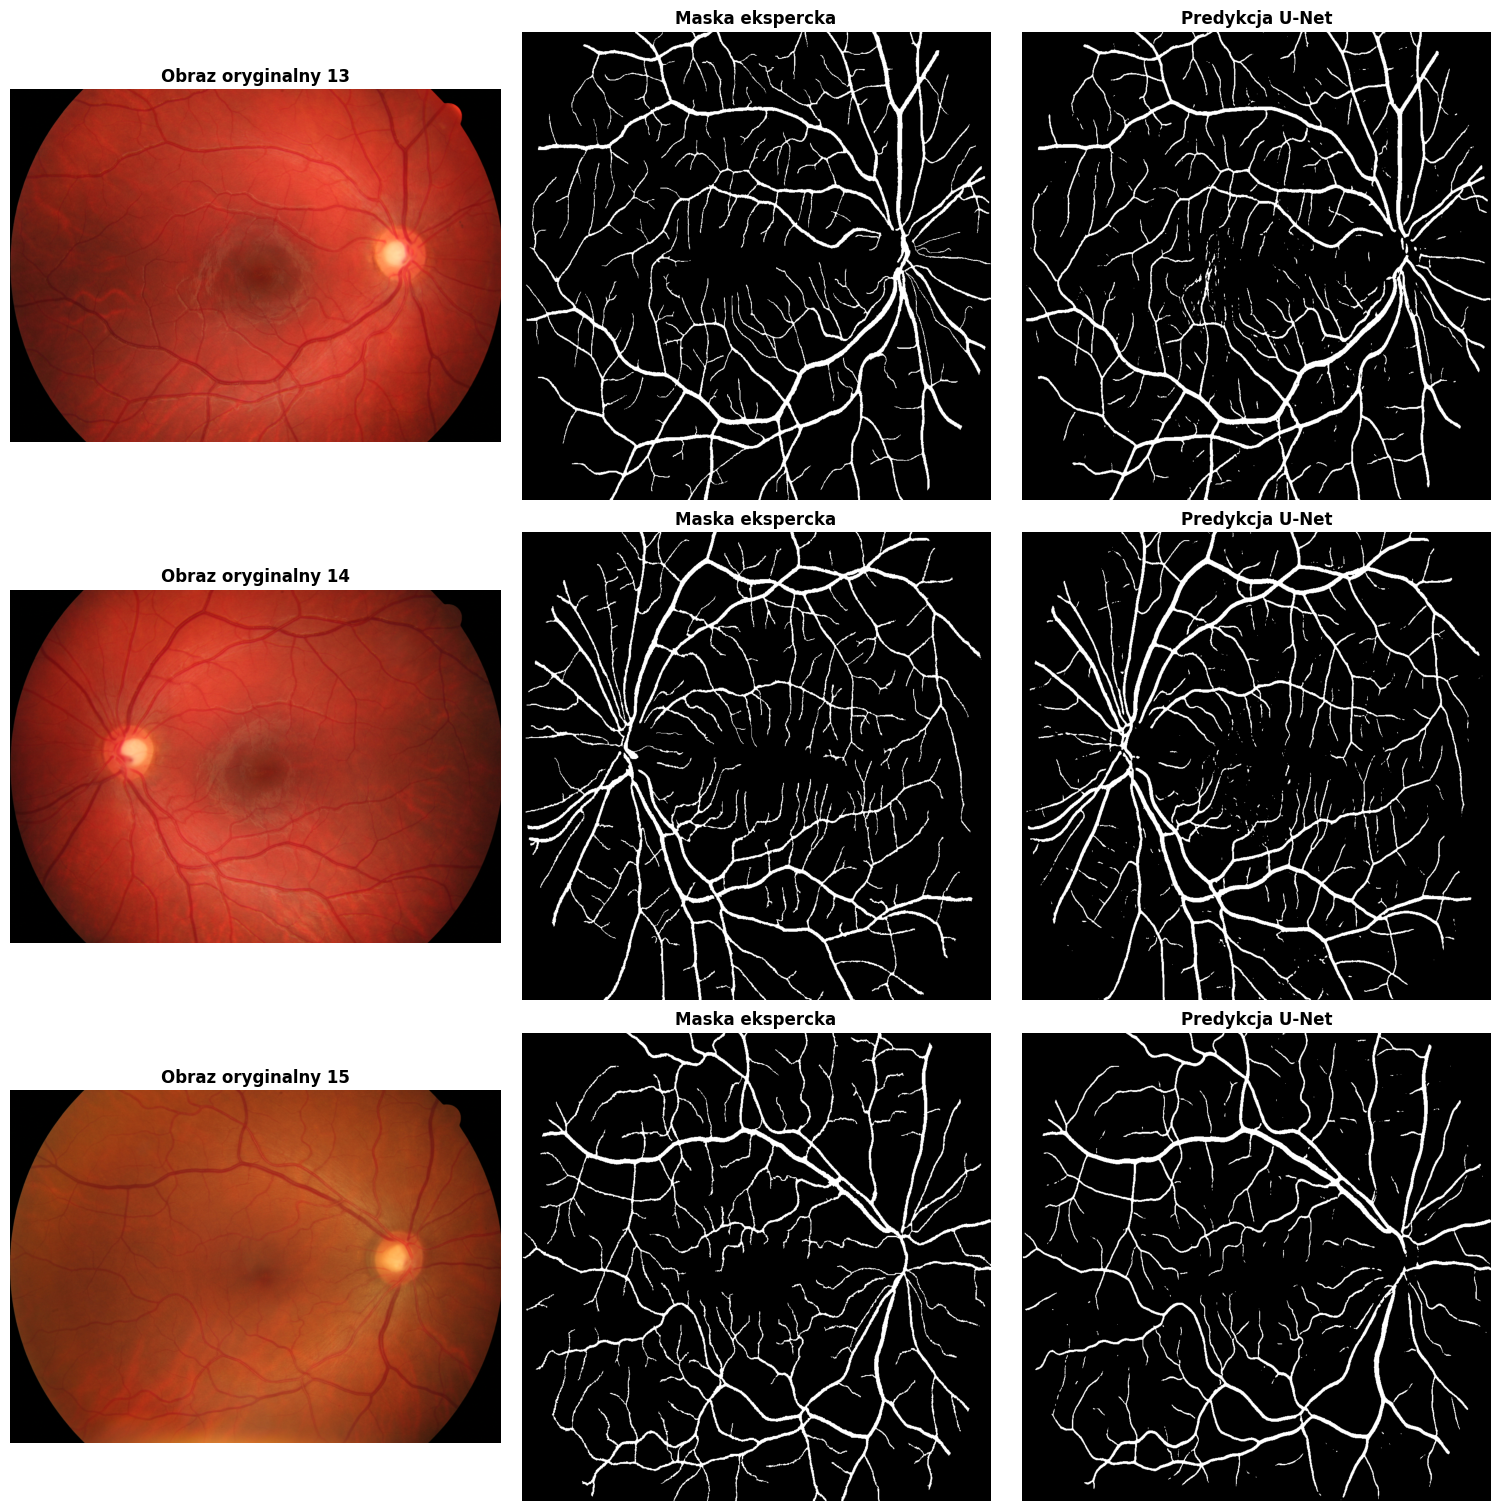

In [ ]:
model.eval()
fig, axes = plt.subplots(len(test_ds), 3, figsize=(15, 5 * len(test_ds)), constrained_layout=True)

with torch.no_grad():
    for i, (img_t, mask_t) in enumerate(test_loader):
        logits   = model(img_t.to(DEVICE))
        prob     = torch.sigmoid(logits).cpu().squeeze().numpy()
        pred_bin = (prob > 0.5).astype(np.uint8)
        gt_bin   = mask_t.squeeze().numpy().astype(np.uint8)

        # Oryginalne zdjęcie z datasetu (raw)
        img_raw = images[12 + i][:, 128:-128]  # raw image z przycinaniem czarnych marginesów

        axes[i, 0].imshow(img_raw)
        axes[i, 0].set_title(f"Obraz oryginalny {i+13}", fontsize=12, fontweight='bold')
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_bin, cmap="gray")
        axes[i, 1].set_title("Maska ekspercka", fontsize=12, fontweight='bold')
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin, cmap="gray")
        axes[i, 2].set_title("Predykcja U-Net", fontsize=12, fontweight='bold')
        axes[i, 2].axis("off")

plt.show()


## notatnik wyników:

### dla wiekszego obrazka bez preprocesingu: (20 epok)
        idx	Acc	Sens	Spec	Bal_A	Bal_G
    13	0.963	0.857	0.973	0.915	0.913
    14	0.961	0.813	0.975	0.894	0.890
    15	0.960	0.536	0.996	0.766	0.731
    avg	0.961	0.735	0.981	0.858	0.845

### + preprocessing i obcięcie czarnych marginesów obrazka oraz adam -> adamW (20 epok)
    idx	Acc	Sens	Spec	Bal_A	Bal_G
    13	0.970	0.873	0.980	0.927	0.925
    14	0.969	0.869	0.979	0.924	0.923
    15	0.974	0.822	0.988	0.905	0.901
    avg	0.971	0.855	0.982	0.919	0.916

### + prosta augmentacja jako lustrzne odbicie, dropout 0.1 w każdym module konwulucji,  chce puścić na wiecej niz 20 epok